<a href="https://colab.research.google.com/github/miriam-silva/ProvaIcomaAM/blob/main/prova_01_miriam_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prova 01:** IBM | Direção Diária:

**Alvo ($Y$):** 1 se Fechamento > Abertura; 0 caso contrário.

**Desafio:** O Naive Bayes prevê altas apenas com base nas variações passadas?

# **Aluna:** Miriam Silva Corrêa



# Pipeline 1 | Extração e Carregamento de Dados [Fase 1]

## Bibliotecas Python

In [95]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Consumo da API (Alpha Vantage)

In [107]:
API_KEY = '6HWAF04BNA14OCVF'
symbol = 'IBM'
url = f'https://www.alphavantage.co/query?function=HISTORICAL_VOLUME_OPEN_INTEREST_RATIO&symbol={symbol}&apikey={API_KEY}&outputsize=compact'
response = requests.get(url)
data = response.json()
bf_data = pd.DataFrame(data['data'])
print(bf_data)

              contractID symbol  expiration  strike  type        date  \
0     IBM260508C00130000    IBM  2026-05-08  130.00  call  2026-05-04   
1     IBM260508P00130000    IBM  2026-05-08  130.00   put  2026-05-04   
2     IBM260508C00135000    IBM  2026-05-08  135.00  call  2026-05-04   
3     IBM260508P00135000    IBM  2026-05-08  135.00   put  2026-05-04   
4     IBM260508C00140000    IBM  2026-05-08  140.00  call  2026-05-04   
...                  ...    ...         ...     ...   ...         ...   
1979  IBM281215P00350000    IBM  2028-12-15  350.00   put  2026-05-04   
1980  IBM281215C00360000    IBM  2028-12-15  360.00  call  2026-05-04   
1981  IBM281215P00360000    IBM  2028-12-15  360.00   put  2026-05-04   
1982  IBM281215C00370000    IBM  2028-12-15  370.00  call  2026-05-04   
1983  IBM281215P00370000    IBM  2028-12-15  370.00   put  2026-05-04   

     volume_open_interest_ratio  
0                          None  
1                    3.00000000  
2                    

## Transformação para DataFrame

In [97]:
if 'Time Series (Daily)' in data:
  df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
  df.columns = ['open', 'high', 'low', 'close', 'volume']
  df = df.astype(float)
  df.index = pd.to_datetime(df.index)
  df = df.sort_index()
  print("Dados carregados com sucesso!")
else:
  print("Erro na API:", data)

Dados carregados com sucesso!


In [98]:
df.head()

,open,high,low,close,volume
2025-12-09,309.630,313.9700,308.7500,310.48,2914275.0
2025-12-10,310.230,314.6900,306.6513,312.67,3411524.0
2025-12-11,312.000,313.4400,308.4000,310.74,2755749.0
2025-12-12,310.570,311.0500,303.3300,309.24,2953374.0
2025-12-15,308.985,311.3629,306.3500,308.66,3566732.0


# Pipeline 2 | Laborização (Feature Engineering) [Fase 2]

## Criação da Variável Alvo (Y)

In [99]:
df['target'] = (df['close'] > df['open']).astype(int)

## Criação de Preditores (X) baseados em Lags

In [100]:
df['variation'] = df['close'] - df['open']
df['prev_variation'] = df['variation'].shift(1)
df['prev_volume'] = df['volume'].shift(1)

df_final = df[['prev_variation', 'prev_volume', 'target']].dropna()

print("Colunas extras removidas e valores nulos excluídos.")
df_final.head()

Colunas extras removidas e valores nulos excluídos.


,prev_variation,prev_volume,target
2025-12-10,0.850,2914275.0,1
2025-12-11,2.440,3411524.0,0
2025-12-12,-1.260,2755749.0,0
2025-12-15,-1.330,2953374.0,0
2025-12-16,-0.325,3566732.0,0


# Pipeline 3 | Tratamento e Normalização [Fase 3]

## Visualização dos dados

In [101]:
df_final.head()

,prev_variation,prev_volume,target
2025-12-10,0.850,2914275.0,1
2025-12-11,2.440,3411524.0,0
2025-12-12,-1.260,2755749.0,0
2025-12-15,-1.330,2953374.0,0
2025-12-16,-0.325,3566732.0,0


## Verificação de valores nulos

In [102]:
X = df_final[['prev_variation', 'prev_volume']]
y = df_final['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dados normalizados com sucesso.")

Dados normalizados com sucesso.


## Separação de variáveis e Normalização (StandardScaler)

In [103]:
X = df_final[['prev_variation', 'prev_volume']]
y = df_final['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pipeline 4 | Vizualização de Dados [Fase 4]

## Gráficos de Fechamento e Volume

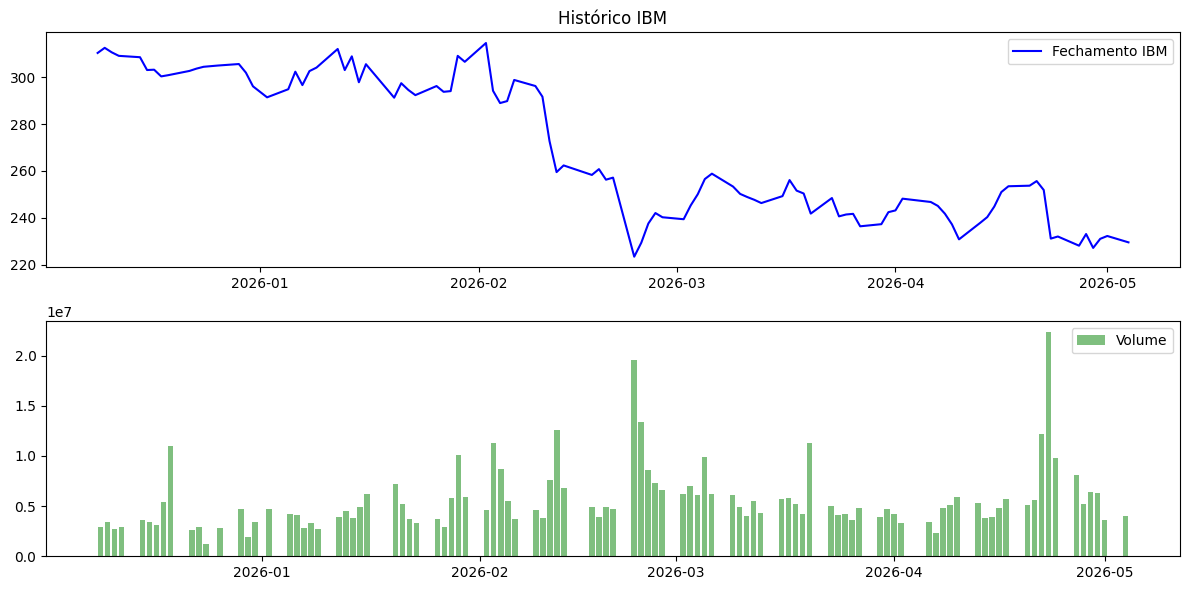

In [104]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['close'], color='blue' , label='Fechamento IBM')
plt.title('Histórico IBM')
plt.legend()

plt.subplot(2, 1, 2)
plt.bar(df.index, df['volume'], color='green', alpha=0.5, label='Volume')
plt.legend()

plt.tight_layout()
plt.show()

# Pipeline 5 | Ingestão Bayesiana [Fase 5]

## Treinamento do Modelo GaussianNB

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

modelo = GaussianNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

## Avaliação e Matriz de Confusão

Acurácia: 55.00%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69        10
           1       1.00      0.10      0.18        10

    accuracy                           0.55        20
   macro avg       0.76      0.55      0.44        20
weighted avg       0.76      0.55      0.44        20



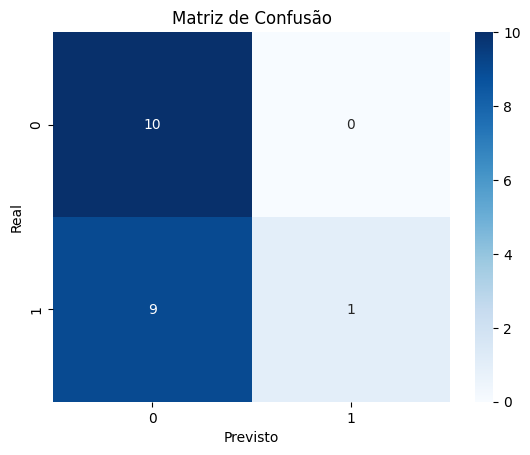

In [106]:
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()